## The Greedy Algorthm
This notebook is comparing the performance of the greedy algorithm with number of agents.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np

from utils.environment import Environment
from main import simulate_greedy_evacuation

n_experiments = 10
num_agents = 20
params = {
        "congestion": True,
        "walking": False,
        "delay_start": False,
        "compliance": 1,
        "fitness": "max-median",
        "alpha": 0.8,
    }

In [13]:
grid_city = Environment('grid_city')
moderate_city = Environment('moderate_city')
bottleneck_city = Environment('bottleneck_city')

In [14]:
rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

### Grid City

In [16]:
num_agents = [10, 20, 50, 100, 200]
grid_city_solutions, grid_city_eval = {n: [] for n in num_agents}, {n: [] for n in num_agents}
for n in num_agents:
    for seed in algorithm_seeds:
        solution, evals = simulate_greedy_evacuation(
            num_agents=n,
            simulation_params=params,
            city=grid_city,
            seed=seed,
            verbose=False
        )
        grid_city_solutions[n].append(solution)
        grid_city_eval[n].append(evals)
    print(f'✅ {n} AGENTS')

✅ 10 AGENTS
✅ 20 AGENTS
✅ 50 AGENTS
✅ 100 AGENTS
✅ 200 AGENTS


In [17]:
grid_city_eval[10][0].metrics

{'Avg path length': np.float64(5.0),
 'Total time': np.int64(6),
 'Average time': np.float64(5.1),
 'Congestion index': np.float64(0.1),
 'Avg Congestion delay': np.float64(0.1),
 'Exit utilisation': np.float64(0.3333333333333333),
 'Avg Path Efficiency': np.float64(1.0)}

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_greedy_scaling(results: dict, city_name: str) -> None:
    agent_counts = sorted(results.keys())
    
    metrics = ["Total time", "Average time", "Avg Congestion delay", "Congestion index", "Exit utilisation"]
    labels = ["Total Time", "Avg Time", "Avg Congestion Delay"]
    colours = ["#378ADD", "#1D9E75", "#D85A30"]

    fig, ax = plt.subplots(figsize=(10, 6))

    for metric, label, colour in zip(metrics, labels, colours):
        means, stds = [], []
        for n in agent_counts:
            values = [d.metrics[metric] for d in results[n]]
            means.append(np.mean(values))
            stds.append(np.std(values))

        means, stds = np.array(means), np.array(stds)
        ax.plot(agent_counts, means, label=label, marker='o', color=colour)
        ax.fill_between(agent_counts, means - stds, means + stds, alpha=0.15, color=colour)

    ax.set_xlabel("Number of Agents")
    ax.set_ylabel("Timesteps")
    ax.set_title(f"Greedy Routing Performance vs Number of Agents for {city_name} City")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [35]:
import pandas as pd

def greedy_scaling_table(results: dict, city_name: str) -> pd.DataFrame:
    agent_counts = sorted(results.keys())
    metrics = ["Total time", "Average time", "Avg Congestion delay", "Congestion index", "Exit utilisation"]

    rows = []
    for n in agent_counts:
        row = {"City": city_name, "Agents": n}
        for metric in metrics:
            values = [d.metrics[metric] for d in results[n]]
            row[f"{metric} (mean)"] = round(float(np.mean(values)), 3)
        rows.append(row)

    return pd.DataFrame(rows).set_index(["City", "Agents"])

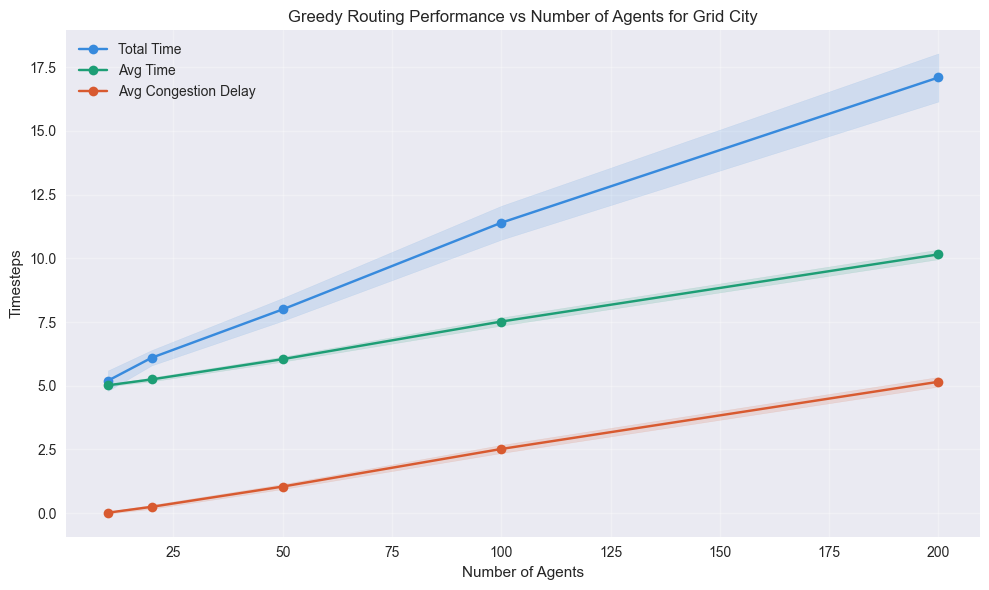

In [22]:
plot_greedy_scaling(grid_city_eval, 'Grid')

In [36]:
greedy_scaling_table(grid_city_eval, 'Grid')

Total time (mean)  Average time (mean)  \
City Agents                                           
Grid 10                    5.2                5.020   
     20                    6.1                5.250   
     50                    8.0                6.046   
     100                  11.4                7.521   
     200                  17.1               10.158   

             Avg Congestion delay (mean)  Congestion index (mean)  \
City Agents                                                         
Grid 10                            0.020                    0.020   
     20                            0.250                    0.245   
     50                            1.046                    0.648   
     100                           2.521                    0.826   
     200                           5.158                    0.909   

             Exit utilisation (mean)  
City Agents                           
Grid 10                        0.247  
     20                        0.277  
     50                        0.209  
     100                       0.201  
     200                       0.179

### Moderate City

In [19]:
num_agents = [10, 20, 50, 100, 200]
moderate_city_solutions, moderate_city_eval = {n: [] for n in num_agents}, {n: [] for n in num_agents}
for n in num_agents:
    for seed in algorithm_seeds:
        solution, evals = simulate_greedy_evacuation(
            num_agents=n,
            simulation_params=params,
            city=moderate_city,
            seed=seed,
            verbose=False
        )
        moderate_city_solutions[n].append(solution)
        moderate_city_eval[n].append(evals)
    print(f'✅ {n} AGENTS')

✅ 10 AGENTS
✅ 20 AGENTS
✅ 50 AGENTS
✅ 100 AGENTS
✅ 200 AGENTS


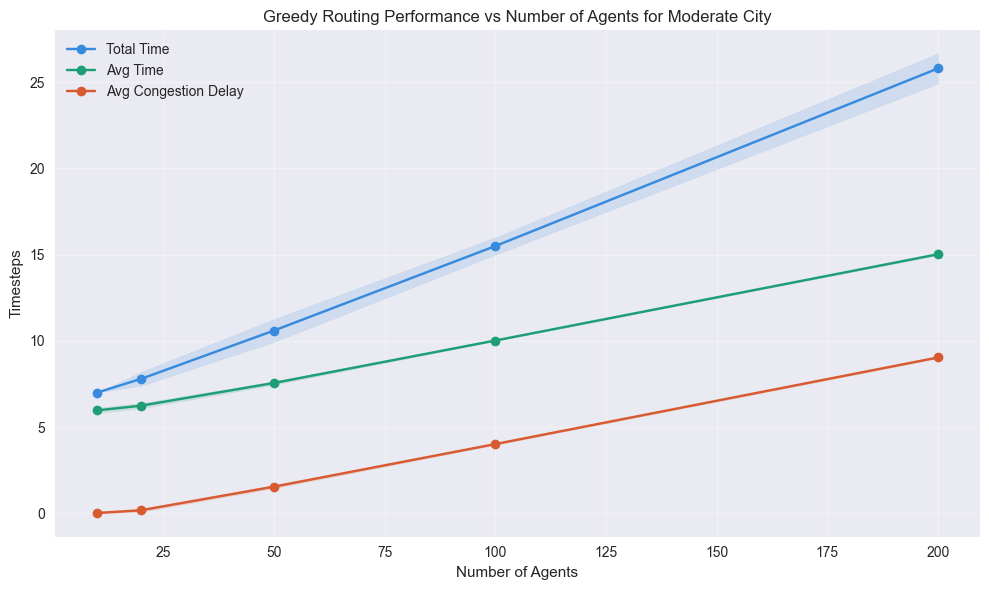

In [31]:
plot_greedy_scaling(moderate_city_eval, 'Moderate')

In [37]:
greedy_scaling_table(moderate_city_eval, 'Moderate')

Total time (mean)  Average time (mean)  \
City     Agents                                           
Moderate 10                    7.0                5.970   
         20                    7.8                6.245   
         50                   10.6                7.560   
         100                  15.5               10.022   
         200                  25.8               15.025   

                 Avg Congestion delay (mean)  Congestion index (mean)  \
City     Agents                                                         
Moderate 10                            0.020                    0.020   
         20                            0.180                    0.165   
         50                            1.548                    0.692   
         100                           4.018                    0.843   
         200                           9.039                    0.926   

                 Exit utilisation (mean)  
City     Agents                           
Moderate 10                        0.090  
         20                        0.060  
         50                        0.052  
         100                       0.027  
         200                       0.022

### Bottleckneck

In [20]:
num_agents = [10, 20, 50, 100, 200]
bottleneck_city_solutions, bottleneck_city_eval = {n: [] for n in num_agents}, {n: [] for n in num_agents}
for n in num_agents:
    for seed in algorithm_seeds:
        solution, evals = simulate_greedy_evacuation(
            num_agents=n,
            simulation_params=params,
            city=bottleneck_city,
            seed=seed,
            verbose=False
        )
        bottleneck_city_solutions[n].append(solution)
        bottleneck_city_eval[n].append(evals)
    print(f'✅ {n} AGENTS')

✅ 10 AGENTS
✅ 20 AGENTS
✅ 50 AGENTS
✅ 100 AGENTS
✅ 200 AGENTS


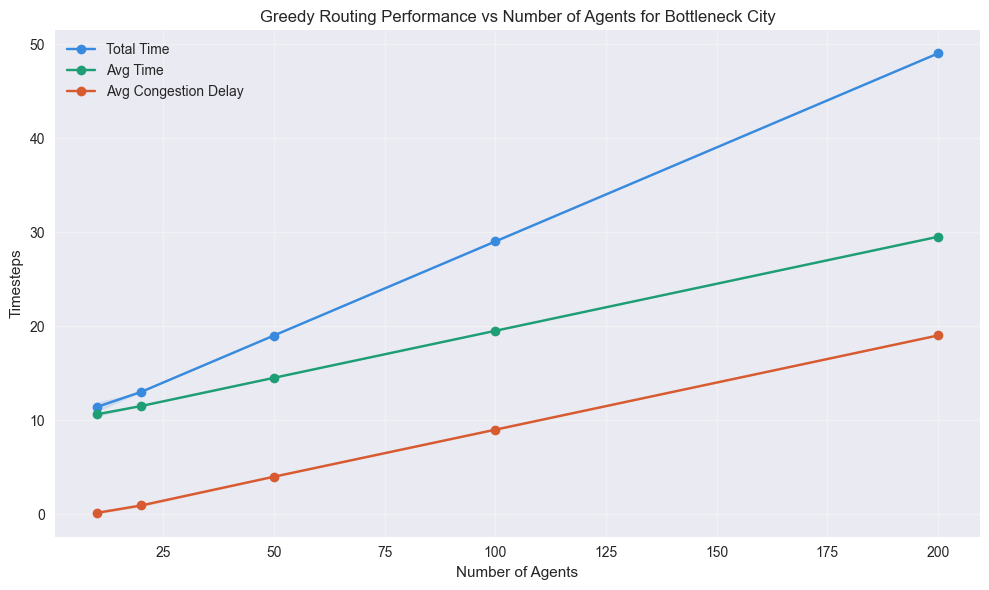

In [24]:
plot_greedy_scaling(bottleneck_city_eval, 'Bottleneck')

In [38]:
greedy_scaling_table(bottleneck_city_eval, 'Bottleneck')

Total time (mean)  Average time (mean)  \
City       Agents                                           
Bottleneck 10                   11.4                10.62   
           20                   13.0                11.50   
           50                   19.0                14.50   
           100                  29.0                19.50   
           200                  49.0                29.50   

                   Avg Congestion delay (mean)  Congestion index (mean)  \
City       Agents                                                         
Bottleneck 10                            0.140                    0.140   
           20                            0.925                    0.650   
           50                            3.984                    0.900   
           100                           8.985                    0.950   
           200                          19.004                    0.975   

                   Exit utilisation (mean)  
City       Agents                           
Bottleneck 10                        0.140  
           20                        0.150  
           50                        0.156  
           100                       0.176  
           200                       0.151

### Panick seed check..

In [39]:
ga_starts = ['S4','S1','S4','S1','S1','S1','S1','S3','S4','S1','S1','S1','S1','S2','S1','S3','S1','S2','S4','S2','S4','S4','S3','S4','S1','S4','S4','S4','S1','S3','S2','S1','S3','S1','S3','S3','S1','S3','S4','S2','S4','S1','S2','S3','S2','S2','S4','S3','S1','S2','S4','S3','S4','S2','S1','S4','S4','S3','S4','S1','S1','S2','S3','S1','S4','S4','S4','S3','S1','S1','S3','S1','S3','S3','S1','S2','S3','S1','S2','S1','S4','S3','S3','S2','S1','S4','S1','S4','S1','S2','S4','S4','S4','S4','S2','S1','S2','S1','S3','S3']

In [46]:
greedy_starts = [str(a.start_point) for a in bottleneck_city_eval[100][0].chromosome.agents.values()]


In [47]:
ga_starts == greedy_starts

True